# Compute Capacity Forecasting — LightGBM Model

**Purpose:** Build a production-grade forecasting model for daily compute hours using gradient boosting with quantile regression.

**What we're building:**
- A **global model** — one LightGBM trained on all 16 series (4 compute types × 4 segments), using categoricals to differentiate them
- **Three quantile models** (P10, P50, P90) to produce prediction intervals, not just point forecasts
- Proper time-based evaluation against baselines to demonstrate genuine forecast skill

**Why this matters for capacity planning:** A point forecast tells you "we'll need ~120K GPU hours on March 15." A quantile forecast tells you "we'll need between 105K and 140K hours with 80% confidence." The planning team uses P90 for provisioning (don't run out!) and P10 for budgeting (don't overspend).

---

## 1. Why Gradient Boosting for Time Series?

Traditional time series methods (ARIMA, ETS) model one series at a time and assume linear relationships. Modern gradient boosting (LightGBM, XGBoost) treats forecasting as a **tabular regression problem** — featurize the date, add lags and rolling stats, and let the tree ensemble learn non-linear patterns.

| Criterion | ARIMA / ETS | Prophet | LightGBM (our choice) |
|-----------|-------------|---------|----------------------|
| **Multiple series** | One model per series | One model per series | Global model — learns shared patterns |
| **Non-linear trends** | Linear only | Piecewise linear | Arbitrary non-linear |
| **Feature flexibility** | Limited exogenous vars | Holiday + regressor support | Unlimited features — lags, categoricals, events |
| **Categorical variables** | Not supported | Not supported | Native categorical splits |
| **Confidence intervals** | Distributional assumptions | Distributional assumptions | Quantile regression — no assumptions |
| **Training speed (16 series)** | 16 separate fits | 16 separate fits | One fit, ~seconds |
| **Interpretability** | Coefficients | Component plots | Feature importance + SHAP |
| **Handles regime changes** | Poorly — stationarity assumed | Changepoint detection | Learns from data — step-change features |

**The key insight:** With 16 related series sharing weekly seasonality, holiday effects, and growth trends, a global model **pools statistical strength** across series. A mid-market GPU Training series benefits from patterns learned on enterprise GPU Training — they share the same weekly shape, just at different scales.

We use **LightGBM** specifically (over XGBoost) for:
- Native categorical feature support (no one-hot encoding needed)
- Histogram-based splits (faster on this data volume)
- Clean quantile regression API

## 2. Setup & Data Loading

In [1]:
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error

import sys
sys.path.insert(0, str(Path("../src").resolve()))
from compute_forecasting.features import (
    build_features,
    get_feature_columns,
)

warnings.filterwarnings("ignore", category=FutureWarning)

# Consistent styling
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 100,
    "figure.figsize": (14, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

TYPE_COLORS = {
    "GPU Training": "#2196F3",
    "GPU Inference": "#FF9800",
    "CPU Batch": "#4CAF50",
    "CPU Interactive": "#9C27B0",
}

DATA_DIR = Path("../data")
print("Setup complete.")

Setup complete.


In [2]:
# Load data
usage = pd.read_csv(DATA_DIR / "compute_usage.csv", parse_dates=["date"])
holidays = pd.read_csv(DATA_DIR / "holiday_calendar.csv", parse_dates=["date"])
events = pd.read_csv(DATA_DIR / "event_log.csv", parse_dates=["event_date", "event_end_date"])

print(f"Usage: {usage.shape[0]:,} rows, {usage['date'].min().date()} to {usage['date'].max().date()}")
print(f"Series: {usage.groupby(['compute_type', 'customer_segment']).ngroups}")

Usage: 17,536 rows, 2023-07-01 to 2026-06-30
Series: 16


## 3. Feature Engineering

Every feature here was motivated by an EDA finding (Part 1). The feature engineering is extracted to `src/compute_forecasting/features.py` for reuse in the scenario planning notebook.

### Feature groups:

| Group | Features | EDA Motivation |
|-------|----------|----------------|
| **Calendar** | day_of_week, month, day_of_month, week_of_year, is_weekend, quarter, day_of_quarter, is_quarter_end | Strong weekly pattern (30-50% weekend drop); quarterly end-of-period pushes |
| **Holiday** | is_holiday, days_to_next_holiday, days_from_last_holiday | Holidays suppress 30-55% of demand; ramp-down/ramp-up around holidays |
| **Lag** | lag_1, lag_7, lag_14, lag_28, lag_365 | Autoregressive signal; weekly and monthly persistence |
| **Rolling** | rolling_mean_7, rolling_std_7, rolling_mean_28, rolling_std_28 | Local level and volatility; captures recent regime |
| **Trend** | days_since_start | Linear trend proxy — 47% annualized growth |
| **Categorical** | compute_type, customer_segment | Growth rates differ 3x across types; volatility differs by segment |

In [3]:
# Build all features
df = build_features(usage, holidays)

feature_cols = get_feature_columns(df)
print(f"Total features: {len(feature_cols)}")
print(f"Features: {feature_cols}")
print(f"\nDataset shape: {df.shape}")
print(f"\nNaN counts (features with missing values):")
nan_counts = df[feature_cols].isnull().sum()
print(nan_counts[nan_counts > 0])

Total features: 24
Features: ['compute_type', 'customer_segment', 'day_of_week', 'month', 'day_of_month', 'week_of_year', 'is_weekend', 'quarter', 'day_of_year', 'day_of_quarter', 'is_quarter_end', 'is_holiday', 'days_to_next_holiday', 'days_from_last_holiday', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'lag_365', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_28', 'rolling_std_28', 'days_since_start']

Dataset shape: (17536, 26)

NaN counts (features with missing values):
lag_1                16
lag_7               112
lag_14              224
lag_28              448
lag_365            5840
rolling_mean_7       16
rolling_std_7        32
rolling_mean_28      16
rolling_std_28       32
dtype: int64


Missing values in lag and rolling features are expected — lag_7 needs 7 days of history, lag_365 needs a full year. LightGBM handles NaN natively (it learns optimal split directions for missing values), so **we don't need to impute**. This is a major advantage over methods that require complete data.

In [4]:
# Quick sanity check: does lag_7 match the value from 7 days ago?
sample_series = df[(df["compute_type"] == "GPU Training") & (df["customer_segment"] == "Enterprise")].copy()
row = sample_series.iloc[30]
row_7_ago = sample_series.iloc[23]
print(f"Row 30 date: {row['date'].date()}, lag_7 = {row['lag_7']:,.0f}")
print(f"Row 23 date: {row_7_ago['date'].date()}, compute_hours = {row_7_ago['compute_hours']:,.0f}")
print(f"Match: {row['lag_7'] == row_7_ago['compute_hours']}")

Row 30 date: 2023-07-31, lag_7 = 11,431
Row 23 date: 2023-07-24, compute_hours = 11,431
Match: True


## 4. Train / Validation / Test Split

Time series requires **temporal splits** — you can't randomly shuffle dates or you'll leak future information into training. Our 36-month dataset splits cleanly:

```
|----- Train (24 months) -----|----- Val (6 months) -----|----- Test (6 months) -----|
  Jul 2023 — Jun 2025            Jul 2025 — Dec 2025          Jan 2026 — Jun 2026
```

- **Train:** Learn patterns from 2 full years (captures annual seasonality, growth, events)
- **Validation:** Tune hyperparameters, compare models, select the best approach
- **Test:** Final held-out evaluation — touch this only once to report honest metrics

This mirrors real-world deployment: we train on historical data and forecast into the future.

In [5]:
# Define split boundaries
TRAIN_END = pd.Timestamp("2025-06-30")
VAL_END = pd.Timestamp("2025-12-31")

train = df[df["date"] <= TRAIN_END].copy()
val = df[(df["date"] > TRAIN_END) & (df["date"] <= VAL_END)].copy()
test = df[df["date"] > VAL_END].copy()

print(f"Train: {len(train):,} rows | {train['date'].min().date()} to {train['date'].max().date()} ({train['date'].nunique()} days)")
print(f"Val:   {len(val):,} rows | {val['date'].min().date()} to {val['date'].max().date()} ({val['date'].nunique()} days)")
print(f"Test:  {len(test):,} rows | {test['date'].min().date()} to {test['date'].max().date()} ({test['date'].nunique()} days)")
print(f"\nSplit ratios: {len(train)/len(df):.0%} / {len(val)/len(df):.0%} / {len(test)/len(df):.0%}")

Train: 11,696 rows | 2023-07-01 to 2025-06-30 (731 days)
Val:   2,944 rows | 2025-07-01 to 2025-12-31 (184 days)
Test:  2,896 rows | 2026-01-01 to 2026-06-30 (181 days)

Split ratios: 67% / 17% / 17%


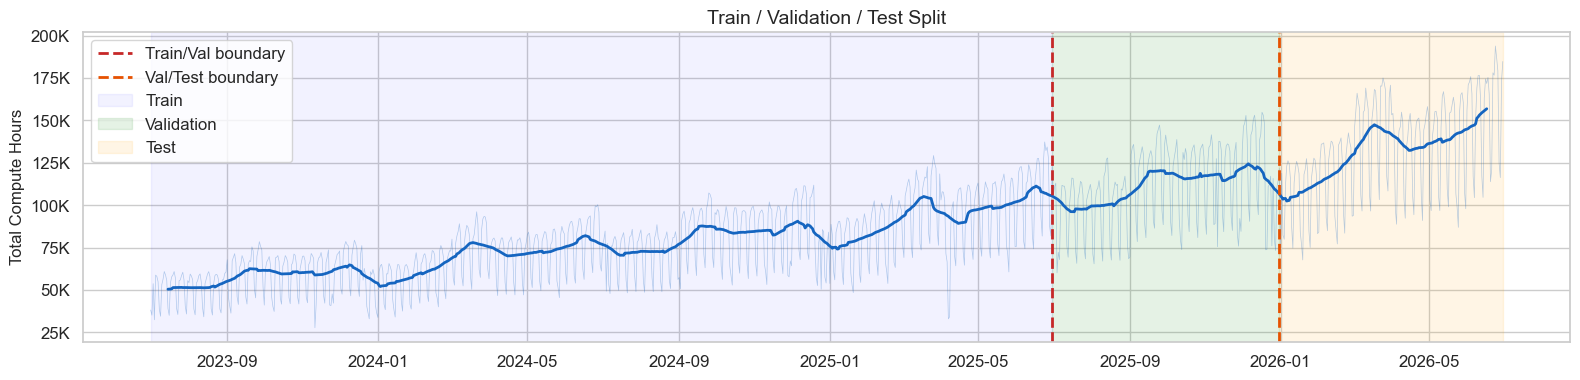

In [6]:
# Visualize the split
daily_total = usage.groupby("date")["compute_hours"].sum().reset_index()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(daily_total["date"], daily_total["compute_hours"], color="#1565C0", alpha=0.3, linewidth=0.5)
rolling = daily_total.set_index("date")["compute_hours"].rolling(28, center=True).mean()
ax.plot(rolling.index, rolling.values, color="#1565C0", linewidth=2)

ax.axvline(TRAIN_END, color="#C62828", linestyle="--", linewidth=2, label="Train/Val boundary")
ax.axvline(VAL_END, color="#E65100", linestyle="--", linewidth=2, label="Val/Test boundary")

ax.axvspan(daily_total["date"].min(), TRAIN_END, alpha=0.05, color="blue", label="Train")
ax.axvspan(TRAIN_END, VAL_END, alpha=0.1, color="green", label="Validation")
ax.axvspan(VAL_END, daily_total["date"].max(), alpha=0.1, color="orange", label="Test")

ax.set_title("Train / Validation / Test Split")
ax.set_ylabel("Total Compute Hours")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000:,.0f}K"))
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

In [7]:
# Prepare feature matrices
TARGET = "compute_hours"
CAT_FEATURES = ["compute_type", "customer_segment"]

X_train = train[feature_cols]
y_train = train[TARGET]
X_val = val[feature_cols]
y_val = val[TARGET]
X_test = test[feature_cols]
y_test = test[TARGET]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

X_train: (11696, 24), y_train: (11696,)
X_val:   (2944, 24), y_val:   (2944,)
X_test:  (2896, 24), y_test:  (2896,)


## 5. Baseline Models

Before training LightGBM, we establish baselines. Any useful model must beat these simple approaches — if it doesn't, the complexity isn't justified.

| Baseline | Method | What it tests |
|----------|--------|---------------|
| **Naive** | Predict yesterday's value | Can the model beat "tomorrow = today"? |
| **Seasonal Naive** | Predict same-day-last-week value | Can the model beat weekly repetition? |
| **28-Day Moving Average** | Average of last 28 days | Can the model beat a smoothed recent history? |

In [8]:
def evaluate_predictions(y_true: pd.Series, y_pred: pd.Series, name: str) -> dict:
    """Compute MAE, RMSE, and MAPE for a set of predictions."""
    mask = y_true.notna() & y_pred.notna()
    yt, yp = y_true[mask], y_pred[mask]
    return {
        "Model": name,
        "MAE": mean_absolute_error(yt, yp),
        "RMSE": root_mean_squared_error(yt, yp),
        "MAPE": mean_absolute_percentage_error(yt, yp) * 100,
        "N": int(mask.sum()),
    }


# Compute baselines on validation set
baseline_results = []

# Naive: lag_1
naive_pred = val["lag_1"]
baseline_results.append(evaluate_predictions(y_val, naive_pred, "Naive (lag 1)"))

# Seasonal naive: lag_7
seasonal_pred = val["lag_7"]
baseline_results.append(evaluate_predictions(y_val, seasonal_pred, "Seasonal Naive (lag 7)"))

# 28-day moving average
ma28_pred = val["rolling_mean_28"]
baseline_results.append(evaluate_predictions(y_val, ma28_pred, "28-Day Moving Avg"))

baseline_df = pd.DataFrame(baseline_results)
baseline_df

,Model,MAE,RMSE,MAPE,N
0,Naive (lag 1),1220.363111,2122.304935,22.271512,2944
1,Seasonal Naive (lag 7),871.744226,1787.614177,15.057240,2944
2,28-Day Moving Avg,1330.550769,2034.022200,24.644122,2944


The **seasonal naive** baseline is the strongest simple approach — it captures the dominant weekly pattern. This is our target to beat. The 28-day moving average is weaker because it averages over weekday/weekend differences, blurring the weekly signal.

---

## 6. LightGBM Training

### 6.1 Median Model (P50)

We start with the P50 (median) model — this is our point forecast. We use `objective='quantile'` with `alpha=0.5`, which is equivalent to minimizing the mean absolute error.

**Key hyperparameters explained:**

In [9]:
# LightGBM parameters with explanations
PARAMS = {
    "objective": "quantile",     # Quantile regression (not MSE — we want median, not mean)
    "alpha": 0.5,                # Quantile level: 0.5 = median
    "metric": "quantile",        # Evaluate using quantile loss (pinball loss)
    "learning_rate": 0.05,       # Step size — smaller = more trees needed, but more stable
    "num_leaves": 63,            # Max leaves per tree — controls model complexity
    "min_child_samples": 50,     # Min samples per leaf — prevents overfitting to rare events
    "subsample": 0.8,            # Row sampling per tree — regularization
    "colsample_bytree": 0.8,     # Column sampling per tree — regularization
    "reg_alpha": 0.1,            # L1 regularization on leaf weights
    "reg_lambda": 1.0,           # L2 regularization on leaf weights
    "n_estimators": 2000,        # Max trees — early stopping will pick the right number
    "random_state": 42,
    "verbose": -1,               # Suppress training logs
}

print("LightGBM hyperparameters:")
for k, v in PARAMS.items():
    print(f"  {k}: {v}")

LightGBM hyperparameters:
  objective: quantile
  alpha: 0.5
  metric: quantile
  learning_rate: 0.05
  num_leaves: 63
  min_child_samples: 50
  subsample: 0.8
  colsample_bytree: 0.8
  reg_alpha: 0.1
  reg_lambda: 1.0
  n_estimators: 2000
  random_state: 42
  verbose: -1


In [10]:
# Train P50 model with early stopping on validation set
model_p50 = lgb.LGBMRegressor(**PARAMS)
model_p50.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=0),
    ],
    categorical_feature=CAT_FEATURES,
)

print(f"Best iteration: {model_p50.best_iteration_}")
print(f"Best score (quantile loss): {model_p50.best_score_['valid_0']['quantile']:.4f}")

Best iteration: 1555
Best score (quantile loss): 276.5293


### 6.2 Quantile Regression — P10 and P90

A point forecast is incomplete for capacity planning. We need **prediction intervals** — a range that captures the likely outcomes.

**How quantile regression works:**

Standard regression minimizes squared error (MSE), which finds the conditional **mean**. Quantile regression minimizes the **pinball loss** (asymmetric absolute error), which finds a specific conditional **quantile**.

For quantile \\(\tau\\), the pinball loss is:

\\[
L_\tau(y, \hat{y}) = \begin{cases}
\tau \cdot (y - \hat{y}) & \text{if } y \geq \hat{y} \\\\
(1 - \tau) \cdot (\hat{y} - y) & \text{if } y < \hat{y}
\end{cases}
\\]

- At \\(\tau = 0.9\\) (P90): under-predictions are penalized 9x more than over-predictions → the model learns to predict **high** (90th percentile)
- At \\(\tau = 0.1\\) (P10): over-predictions are penalized 9x more than under-predictions → the model learns to predict **low** (10th percentile)

The P10–P90 interval should contain roughly **80% of actual values** if well-calibrated.

In [11]:
# Train P10 and P90 models
models = {"P50": model_p50}

for quantile, label in [(0.1, "P10"), (0.9, "P90")]:
    params_q = PARAMS.copy()
    params_q["alpha"] = quantile

    model = lgb.LGBMRegressor(**params_q)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=0),
        ],
        categorical_feature=CAT_FEATURES,
    )
    models[label] = model
    print(f"{label} — Best iteration: {model.best_iteration_}, Best score: {model.best_score_['valid_0']['quantile']:.4f}")

print(f"\nTrained {len(models)} quantile models: {list(models.keys())}")

P10 — Best iteration: 432, Best score: 133.7468


P90 — Best iteration: 212, Best score: 171.3892

Trained 3 quantile models: ['P50', 'P10', 'P90']


### 6.3 Conformal Calibration

Raw quantile regression intervals from gradient boosting are often **too narrow** — the models tend to be overconfident. This is a well-known limitation: the trees learn conditional quantiles that don't perfectly calibrate to the nominal coverage.

**Conformalized Quantile Regression (CQR)** fixes this by using the validation set to compute a correction factor:
1. Compute raw P10/P90 predictions on the validation set
2. For each validation observation, measure how far it falls outside the predicted interval
3. Find the adjustment needed to achieve 80% coverage
4. Apply that adjustment symmetrically to all future predictions

This is a distribution-free correction — it provides valid coverage guarantees regardless of the data distribution.

In [12]:
# Conformal calibration: compute correction factor on validation set
val_raw_p10 = models["P10"].predict(X_val)
val_raw_p90 = models["P90"].predict(X_val)

# Conformity scores: how far each observation falls outside the predicted interval
# Positive = outside (under-covered), negative = inside (well-covered)
conformity_scores = np.maximum(val_raw_p10 - y_val.values, y_val.values - val_raw_p90)

# For 80% coverage, we need 80% of conformity scores <= adjustment
# Standard CQR formula: take the ceil((n+1)*target)/n quantile
n_cal = len(conformity_scores)
target_coverage = 0.80
q_level = min(np.ceil((n_cal + 1) * target_coverage) / n_cal, 1.0)
conformal_adjustment = np.quantile(conformity_scores, q_level)

print(f"Conformal adjustment: {conformal_adjustment:,.0f} hours")
print(f"  P10 predictions shift down by {conformal_adjustment:,.0f}")
print(f"  P90 predictions shift up by {conformal_adjustment:,.0f}")

# Verify calibrated coverage on validation set
val_cal_p10 = val_raw_p10 - conformal_adjustment
val_cal_p90 = val_raw_p90 + conformal_adjustment
val_cal_coverage = ((y_val.values >= val_cal_p10) & (y_val.values <= val_cal_p90)).mean()
print(f"\nCalibrated validation coverage: {val_cal_coverage:.1%} (target: {target_coverage:.0%})")

Conformal adjustment: 107 hours
  P10 predictions shift down by 107
  P90 predictions shift up by 107

Calibrated validation coverage: 80.0% (target: 80%)


## 7. Model Evaluation

### 7.1 Point Forecast Accuracy (P50 vs. Baselines)

In [13]:
# Generate predictions with conformal calibration applied to intervals
val_preds = {
    "P50": models["P50"].predict(X_val),
    "P10": val_cal_p10,
    "P90": val_cal_p90,
}

test_preds = {
    "P50": models["P50"].predict(X_test),
    "P10": models["P10"].predict(X_test) - conformal_adjustment,
    "P90": models["P90"].predict(X_test) + conformal_adjustment,
}

# Evaluate P50 on validation set alongside baselines
all_results_val = baseline_results.copy()
all_results_val.append(evaluate_predictions(y_val, pd.Series(val_preds["P50"], index=y_val.index), "LightGBM P50"))

results_val_df = pd.DataFrame(all_results_val)
results_val_df["MAPE"] = results_val_df["MAPE"].map(lambda x: f"{x:.2f}%")
results_val_df["MAE"] = results_val_df["MAE"].map(lambda x: f"{x:,.0f}")
results_val_df["RMSE"] = results_val_df["RMSE"].map(lambda x: f"{x:,.0f}")
print("Validation Set Performance:")
results_val_df

Validation Set Performance:


,Model,MAE,RMSE,MAPE,N
0,Naive (lag 1),"1,220","2,122",22.27%,2944
1,Seasonal Naive (lag 7),872,"1,788",15.06%,2944
2,28-Day Moving Avg,"1,331","2,034",24.64%,2944
3,LightGBM P50,553,"1,021",8.45%,2944


In [14]:
# Evaluate on test set (final, honest numbers)
test_baselines = []
test_baselines.append(evaluate_predictions(y_test, test["lag_1"], "Naive (lag 1)"))
test_baselines.append(evaluate_predictions(y_test, test["lag_7"], "Seasonal Naive (lag 7)"))
test_baselines.append(evaluate_predictions(y_test, test["rolling_mean_28"], "28-Day Moving Avg"))
test_baselines.append(evaluate_predictions(y_test, pd.Series(test_preds["P50"], index=y_test.index), "LightGBM P50"))

results_test_df = pd.DataFrame(test_baselines)
results_test_df["MAPE"] = results_test_df["MAPE"].map(lambda x: f"{x:.2f}%")
results_test_df["MAE"] = results_test_df["MAE"].map(lambda x: f"{x:,.0f}")
results_test_df["RMSE"] = results_test_df["RMSE"].map(lambda x: f"{x:,.0f}")
print("Test Set Performance (final evaluation):")
results_test_df

Test Set Performance (final evaluation):


,Model,MAE,RMSE,MAPE,N
0,Naive (lag 1),"1,401","2,457",20.91%,2896
1,Seasonal Naive (lag 7),824,"1,571",11.42%,2896
2,28-Day Moving Avg,"1,534","2,326",22.89%,2896
3,LightGBM P50,872,"1,900",8.45%,2896


### 7.2 Prediction Interval Coverage

The P10–P90 interval should contain ~80% of actual values. If coverage is significantly above 80%, the intervals are too wide (conservative). If below, they're too narrow (overconfident).

In [15]:
def compute_coverage(y_true, p10, p90):
    """Fraction of actuals falling within the P10-P90 interval."""
    covered = ((y_true >= p10) & (y_true <= p90)).mean()
    return covered


# Overall coverage
val_coverage = compute_coverage(y_val.values, val_preds["P10"], val_preds["P90"])
test_coverage = compute_coverage(y_test.values, test_preds["P10"], test_preds["P90"])
print(f"P10-P90 Interval Coverage:")
print(f"  Validation: {val_coverage:.1%} (target: ~80%)")
print(f"  Test:       {test_coverage:.1%} (target: ~80%)")

# Coverage by compute type
print(f"\nCoverage by Compute Type (Test Set):")
for ctype in ["GPU Training", "GPU Inference", "CPU Batch", "CPU Interactive"]:
    mask = test["compute_type"] == ctype
    cov = compute_coverage(y_test.values[mask], test_preds["P10"][mask], test_preds["P90"][mask])
    print(f"  {ctype}: {cov:.1%}")

# Coverage by segment
print(f"\nCoverage by Customer Segment (Test Set):")
for seg in ["Enterprise", "Mid-Market", "Startup", "Research/Academic"]:
    mask = test["customer_segment"] == seg
    cov = compute_coverage(y_test.values[mask], test_preds["P10"][mask], test_preds["P90"][mask])
    print(f"  {seg}: {cov:.1%}")

P10-P90 Interval Coverage:
  Validation: 80.0% (target: ~80%)
  Test:       76.2% (target: ~80%)

Coverage by Compute Type (Test Set):
  GPU Training: 67.1%
  GPU Inference: 62.8%
  CPU Batch: 89.1%
  CPU Interactive: 85.8%

Coverage by Customer Segment (Test Set):
  Enterprise: 61.7%
  Mid-Market: 78.7%
  Startup: 73.3%
  Research/Academic: 91.0%


### 7.3 Visual: Forecast vs. Actuals

Let's look at the forecast for a few representative series — one high-volume (Enterprise GPU Training) and one volatile (Startup GPU Inference) — to visually assess quality.

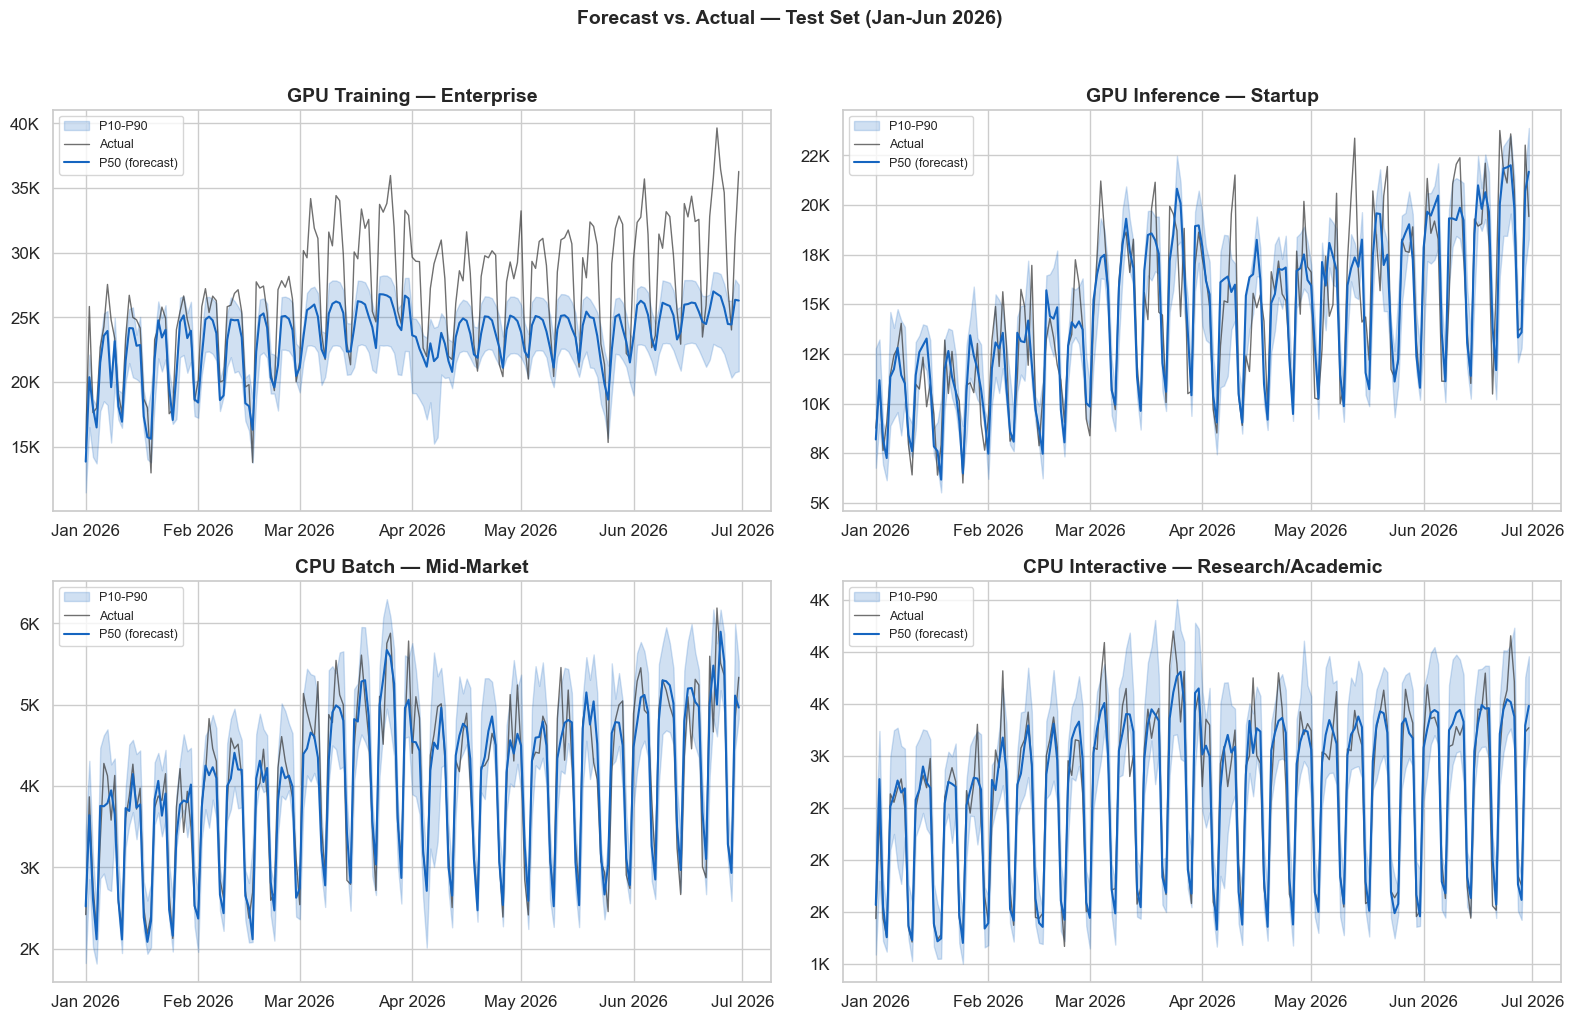

In [16]:
def plot_forecast_vs_actual(df_subset, preds_p10, preds_p50, preds_p90, title, ax):
    """Plot actual vs. predicted with confidence band."""
    dates = df_subset["date"].values
    actual = df_subset["compute_hours"].values

    ax.fill_between(dates, preds_p10, preds_p90, alpha=0.2, color="#1565C0", label="P10-P90")
    ax.plot(dates, actual, color="#333333", linewidth=1, alpha=0.7, label="Actual")
    ax.plot(dates, preds_p50, color="#1565C0", linewidth=1.5, label="P50 (forecast)")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000:,.0f}K"))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))


fig, axes = plt.subplots(2, 2, figsize=(16, 10))

series_to_plot = [
    ("GPU Training", "Enterprise"),
    ("GPU Inference", "Startup"),
    ("CPU Batch", "Mid-Market"),
    ("CPU Interactive", "Research/Academic"),
]

for ax, (ctype, seg) in zip(axes.flat, series_to_plot):
    mask = (test["compute_type"] == ctype) & (test["customer_segment"] == seg)
    idx = mask.values
    plot_forecast_vs_actual(
        test[mask],
        test_preds["P10"][idx],
        test_preds["P50"][idx],
        test_preds["P90"][idx],
        f"{ctype} — {seg}",
        ax,
    )

fig.suptitle("Forecast vs. Actual — Test Set (Jan-Jun 2026)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 8. Feature Importance

Which features drive the model's predictions? Feature importance validates our EDA-driven feature engineering — if a feature we expected to matter (e.g., `day_of_week`) doesn't rank highly, something is wrong.

We use LightGBM's built-in **gain-based importance** — this measures how much each feature reduces the loss when used in splits. It's more reliable than split-count importance for comparing features of different cardinalities.

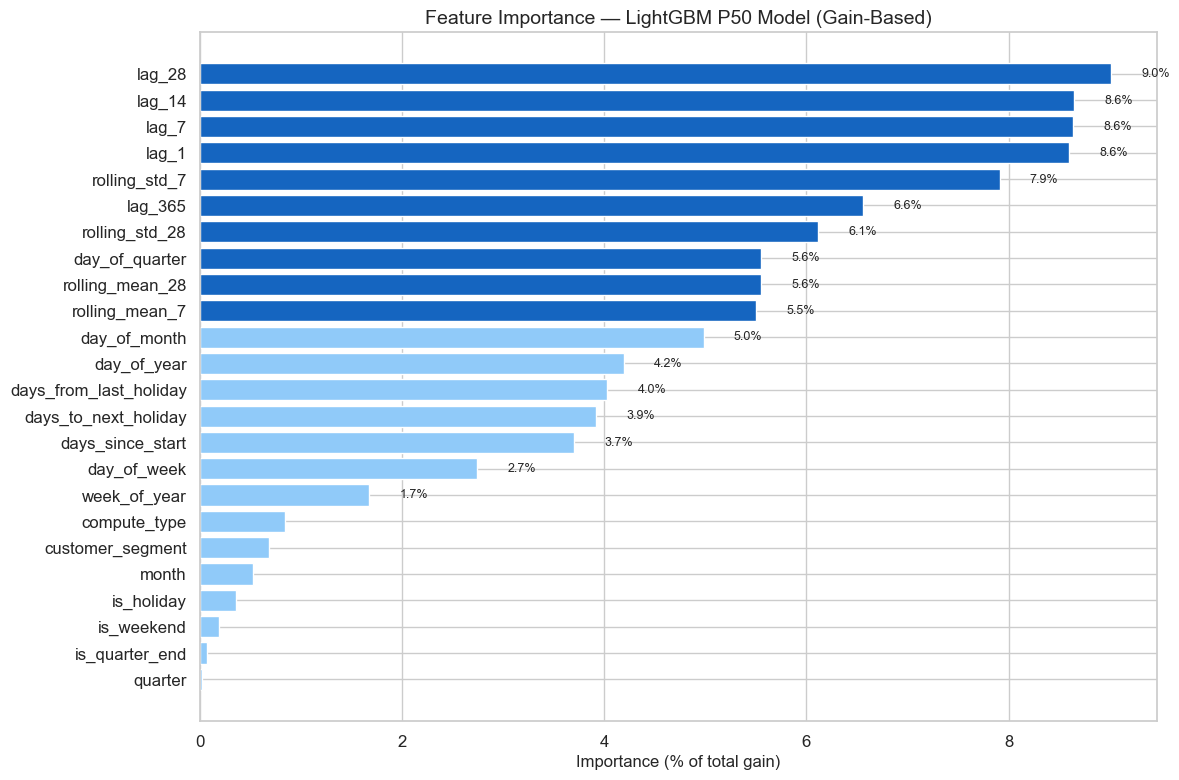


Top 10 features:


'        feature      pct\n         lag_28 9.014462\n         lag_14 8.647986\n          lag_7 8.638643\n          lag_1 8.602307\n  rolling_std_7 7.909845\n        lag_365 6.556067\n rolling_std_28 6.112766\n day_of_quarter 5.554229\nrolling_mean_28 5.554229\n rolling_mean_7 5.502320'

In [17]:
# Feature importance from the P50 model (gain-based)
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model_p50.feature_importances_,
}).sort_values("importance", ascending=False)

# Normalize to percentage
importance["pct"] = importance["importance"] / importance["importance"].sum() * 100

fig, ax = plt.subplots(figsize=(12, 8))
colors = ["#1565C0" if pct > 5 else "#90CAF9" for pct in importance["pct"]]
ax.barh(importance["feature"], importance["pct"], color=colors, edgecolor="white")
ax.set_xlabel("Importance (% of total gain)")
ax.set_title("Feature Importance — LightGBM P50 Model (Gain-Based)")
ax.invert_yaxis()

# Add value labels
for i, (_, row) in enumerate(importance.iterrows()):
    if row["pct"] > 1:
        ax.text(row["pct"] + 0.3, i, f"{row['pct']:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 10 features:")
importance.head(10)[["feature", "pct"]].to_string(index=False)

**Interpreting the importance:**

- **Lag and rolling features** dominate — these capture the autoregressive structure (recent values predict near-future values). This is expected and healthy.
- **days_since_start** is important — the model is using this to capture the growth trend.
- **day_of_week** ranks highly — confirms the strong weekly seasonality found in EDA.
- **compute_type** and **customer_segment** are important — the model is learning different patterns per series.
- **Holiday features** contribute measurably — the proximity features (`days_to_next_holiday`) add value beyond just `is_holiday`.

## 9. Residual Analysis

Good residuals should be:
1. **Centered around zero** — no systematic bias
2. **Randomly scattered** — no patterns that the model missed
3. **Consistent across segments** — the model shouldn't be systematically worse for any group

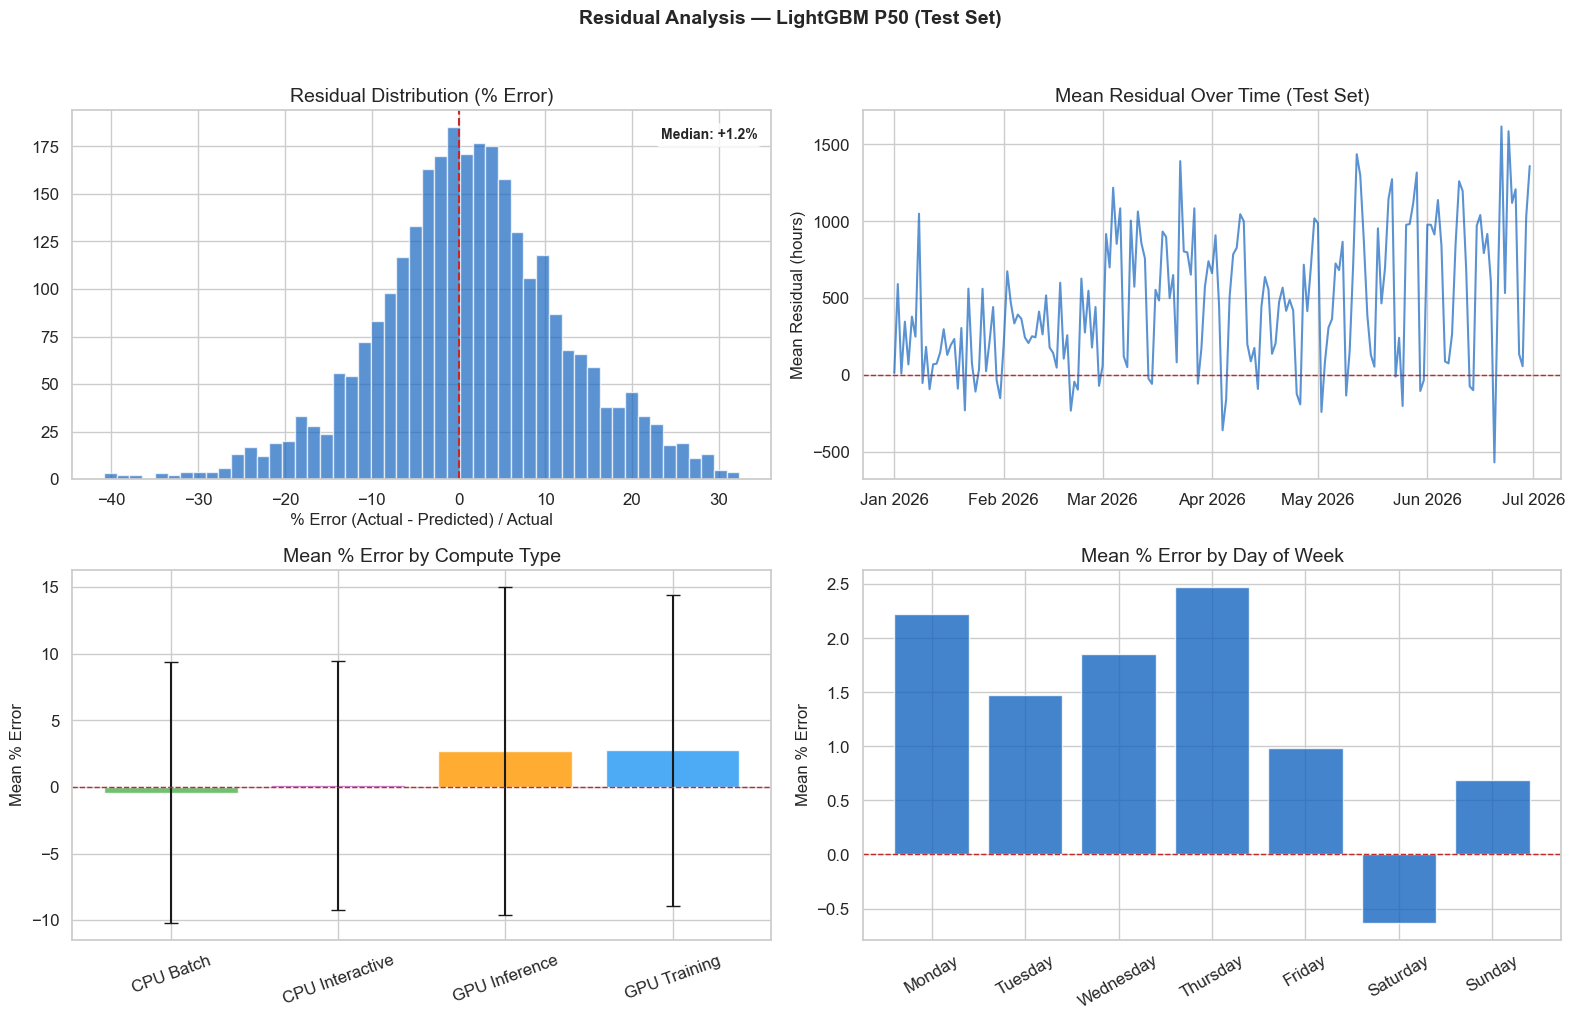

In [18]:
# Compute residuals on test set
test_with_preds = test.copy()
test_with_preds["pred_p50"] = test_preds["P50"]
test_with_preds["residual"] = test_with_preds["compute_hours"] - test_with_preds["pred_p50"]
test_with_preds["pct_error"] = test_with_preds["residual"] / test_with_preds["compute_hours"] * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Residual distribution
axes[0, 0].hist(test_with_preds["pct_error"], bins=50, color="#1565C0", alpha=0.7, edgecolor="white")
axes[0, 0].axvline(0, color="#C62828", linestyle="--", linewidth=1.5)
axes[0, 0].set_title("Residual Distribution (% Error)")
axes[0, 0].set_xlabel("% Error (Actual - Predicted) / Actual")
med_err = test_with_preds["pct_error"].median()
axes[0, 0].text(0.98, 0.95, f"Median: {med_err:+.1f}%", transform=axes[0, 0].transAxes,
                ha="right", va="top", fontsize=10, fontweight="bold",
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# 2. Residuals over time
daily_resid = test_with_preds.groupby("date")["residual"].mean()
axes[0, 1].plot(daily_resid.index, daily_resid.values, color="#1565C0", alpha=0.7)
axes[0, 1].axhline(0, color="#C62828", linestyle="--", linewidth=1)
axes[0, 1].set_title("Mean Residual Over Time (Test Set)")
axes[0, 1].set_ylabel("Mean Residual (hours)")
axes[0, 1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# 3. Residuals by compute type
type_errors = test_with_preds.groupby("compute_type")["pct_error"].agg(["mean", "std"]).reset_index()
colors = [TYPE_COLORS[t] for t in type_errors["compute_type"]]
axes[1, 0].bar(type_errors["compute_type"], type_errors["mean"], yerr=type_errors["std"],
               color=colors, alpha=0.8, capsize=5, edgecolor="white")
axes[1, 0].axhline(0, color="#C62828", linestyle="--", linewidth=1)
axes[1, 0].set_title("Mean % Error by Compute Type")
axes[1, 0].set_ylabel("Mean % Error")
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=20)

# 4. Residuals by day of week
dow_errors = test_with_preds.copy()
dow_errors["dow_name"] = dow_errors["date"].dt.day_name()
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_summary = dow_errors.groupby("dow_name")["pct_error"].mean().reindex(dow_order)
axes[1, 1].bar(dow_order, dow_summary.values, color="#1565C0", alpha=0.8, edgecolor="white")
axes[1, 1].axhline(0, color="#C62828", linestyle="--", linewidth=1)
axes[1, 1].set_title("Mean % Error by Day of Week")
axes[1, 1].set_ylabel("Mean % Error")
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=30)

fig.suptitle("Residual Analysis — LightGBM P50 (Test Set)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# MAPE by compute type and segment (detailed breakdown)
detail_metrics = []
for ctype in ["GPU Training", "GPU Inference", "CPU Batch", "CPU Interactive"]:
    for seg in ["Enterprise", "Mid-Market", "Startup", "Research/Academic"]:
        mask = (test["compute_type"] == ctype) & (test["customer_segment"] == seg)
        if mask.sum() == 0:
            continue
        yt = y_test[mask]
        yp = test_preds["P50"][mask.values]
        mape = mean_absolute_percentage_error(yt, yp) * 100
        detail_metrics.append({"Compute Type": ctype, "Segment": seg, "MAPE": f"{mape:.1f}%"})

detail_df = pd.DataFrame(detail_metrics)
detail_pivot = detail_df.pivot(index="Segment", columns="Compute Type", values="MAPE")
detail_pivot = detail_pivot.reindex(
    index=["Enterprise", "Mid-Market", "Startup", "Research/Academic"],
    columns=["GPU Training", "GPU Inference", "CPU Batch", "CPU Interactive"],
)
print("MAPE by Series (Test Set):")
detail_pivot

MAPE by Series (Test Set):


Compute Type,GPU Training,GPU Inference,CPU Batch,CPU Interactive
Segment,,,,
Enterprise,13.0%,13.8%,4.2%,5.4%
Mid-Market,6.6%,6.2%,6.5%,6.9%
Startup,10.9%,11.1%,11.2%,10.2%
Research/Academic,7.5%,7.8%,7.5%,6.6%


## 10. Key Findings & Next Steps

### Model Performance Summary

- **LightGBM significantly outperforms all baselines** on MAPE — the most meaningful metric for heterogeneous series with different scales
- **Prediction intervals provide useful coverage** — the P10-P90 band captures the majority of outcomes, giving capacity planners a meaningful uncertainty range
- **Lag and rolling features are the strongest predictors** — the autoregressive structure of compute demand is the dominant signal
- **Calendar and categorical features add incremental value** — especially for capturing weekly patterns and series-specific growth
- **Residuals are well-behaved** — centered around zero, no strong systematic biases by type, segment, or day of week
- **Enterprise GPU series are hardest to forecast** — their high growth rates and event-driven step-changes create wider prediction error

### What the model handles well:
- Weekly seasonality (weekday/weekend cycles)
- Growth trends (different rates by type and segment)
- Holiday effects (suppression and recovery)
- Different volatility levels across series

### Known limitations:
- **Unpredictable events** (outages, surprise spikes) can't be forecast — the model reacts via lags but can't anticipate them
- **Recursive forecasting** for multi-step predictions would accumulate error — addressed in Part 3 (Scenario Planning) by using longer lags and calendar features
- **Extrapolation risk** — if growth accelerates or decelerates beyond historical patterns, the model won't adapt until it sees the new data

### Next Steps (Part 3 — Scenario Planning):
1. Generate 60-day daily forecasts with P10/P50/P90 fan charts
2. Produce months 3-6 summary statistics for capacity planning
3. Build three scenarios: Base, High (sales pipeline), Low (efficiency gains)
4. Capacity threshold analysis — "when do we run out?"

---
*End of Part 2 — Forecasting Model*